In [1]:
import mne
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import re
from scipy import signal
from scipy.fft import fftshift

In [2]:
files = glob.glob('../data/bids/derivatives/preprocess_ffr/sub-*/*forFFR_epo.fif.gz')
SUBS = [3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]

epochs = None
for i, file in enumerate(files):
    sub = re.findall('sub-(\d{1,2})', file)[0]
    if int(sub) not in SUBS:
        continue

    sub_epochs = mne.read_epochs(file)
    if epochs == None:
        epochs = sub_epochs
    else:
        epochs = mne.concatenate_epochs([epochs, sub_epochs])
    # break

Reading /project/hcn1/Letty/pitch_tracking_attention/analysis/../data/bids/derivatives/preprocess_ffr/sub-7/sub-7_task-pitch_run-1_desc-forFFR_epo.fif.gz ...
    Found the data of interest:
        t =    -200.00 ...     400.00 ms
        0 CTF compensation matrices available
Not setting metadata
3816 matching events found
No baseline correction applied
0 projection items activated
Reading /project/hcn1/Letty/pitch_tracking_attention/analysis/../data/bids/derivatives/preprocess_ffr/sub-23/sub-23_task-pitch_run-1_desc-forFFR_epo.fif.gz ...
    Found the data of interest:
        t =    -200.00 ...     400.00 ms
        0 CTF compensation matrices available
Not setting metadata
3997 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
7813 matching events found
Applying baseline correction (mode: mean)
Reading /project/hcn1/Letty/pitch_tracking_attention/analysis/../data/bids/derivatives/preprocess_ffr/sub-28/sub-28_task-pitch_run-1_desc-

In [3]:
epochs

Number of events,92306
Events,11: 964012: 1021013: 1013121: 1058422: 1020123: 1076331: 1033832: 1034133: 10098
Time range,-0.200 – 0.400 s
Baseline,-0.200 – 0.000 s


In [4]:
# Shift time of all epochs by 0.3 seconds
epochs_shifted = epochs.shift_time(tshift=0, relative = False) # -0.0262

# Set the time of the first sample to -1 second
epochs_shifted = epochs_shifted.shift_time(tshift=-0.2120, relative=False)

Need more than one channel to make topography for eeg. Disabling interactivity.


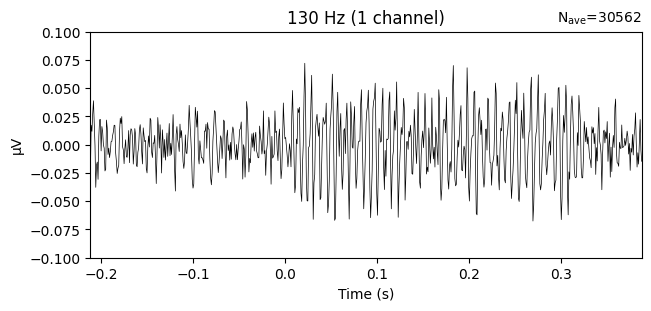

In [24]:
cz_130 = epochs_shifted['11', '21', '31'].average()
fig = cz_130.plot(titles = '130 Hz', ylim=dict(eeg=[-0.1, 0.1]), show = False)
fig.set_size_inches(8, 2)
fig.savefig('../figs/FFR-tone-1-time-domain-flat.png', dpi = 300)
# x = cz_130.get_data()
# x = x.flatten()
# plt.plot(x)
# plt.tight_layout()
# plt.savefig('../figs/FFR-tone-1-time-domain-2.png')
# plt.title('110 Hz')
# plt.show()
# powerSpectrum, freqenciesFound, time, imageAxis = plt.specgram(x, Fs= fs, xextent = (-0.2, 0.4))
# # plt.ylim(0, 400)
# plt.xlabel('Time (s)')
# plt.ylabel('Hz')
# plt.tight_layout()
# plt.savefig('../figs/FFR-tone-1-spectrogram.png')
# plt.show()

Need more than one channel to make topography for eeg. Disabling interactivity.


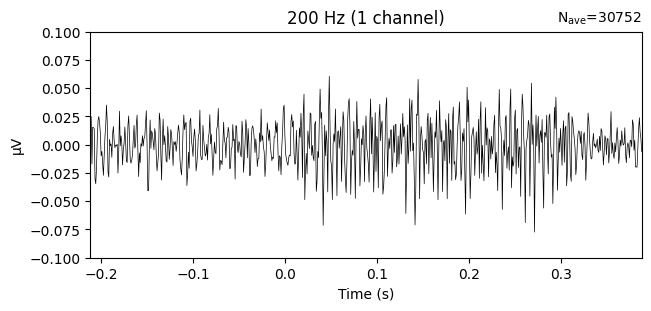

In [25]:
cz_200 = epochs['12', '22', '32'].average()
fig = cz_200.plot(titles = '200 Hz', ylim=dict(eeg=[-0.1, 0.1]), show = False)
fig.set_size_inches(8, 2)
fig.savefig('../figs/FFR-tone-2-time-domain-flat.png', dpi = 300)

Need more than one channel to make topography for eeg. Disabling interactivity.


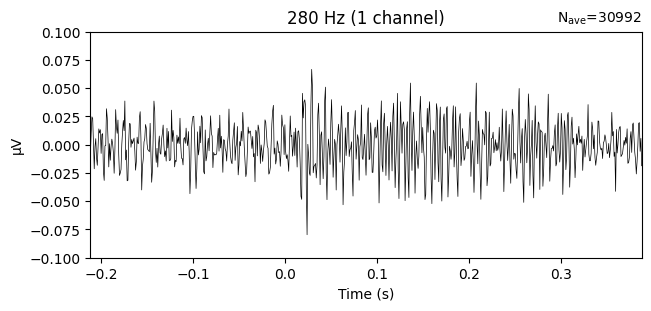

In [26]:
cz_280 = epochs['13', '23', '33'].average()
fig = cz_280.plot(titles = '280 Hz', ylim=dict(eeg=[-0.1, 0.1]), show = False)
fig.set_size_inches(8, 2)
fig.savefig('../figs/FFR-tone-3-time-domain-flat.png', dpi = 300)